# Estimation Tutorial

SSJ now offers a wide range of modular tools which aid in efficient estimation of DSGE models.

In [1]:
from sequence_jacobian import create_model, ShockDict, AR
from sequence_jacobian.estimation import *

import numpy as np

To begin, import any one of our included examples. For demonstration, let's consider an RBC model

In [2]:
from sequence_jacobian.examples.rbc import *

blocks = [household, firm, mkt_clearing]
rbc_model = create_model(blocks, name="RBC")

Suppose we calibrate the model like so:

In [3]:
calibration = {
    "eis": 1.0,
    "frisch": 1.0,
    "delta": 0.025,
    "alpha": 0.11,
    "L": 1.0
}

And solve for the steady state with a hybrid solver (even though this can be done analytically)

In [4]:
unknowns_ss = {"vphi": 0.92, "beta": 1 / (1 + 0.01), "K": 2.0, "Z": 1.0}
targets_ss = {"goods_mkt": 0.0, "r": 0.01, "euler": 0.0, "Y": 1.0}

ss = rbc_model.solve_steady_state(calibration, unknowns_ss, targets_ss, solver="hybr")

In [5]:
unknowns = ["K", "L"]
targets = ["goods_mkt", "euler"]
exogenous = ["Z"]
outputs = ["K"]
T = 300

We also make some additional imports for data generation and plotting utilities

In [6]:
from sequence_jacobian.utilities.shocks import simulate, get_responses
from sequence_jacobian.utilities.plotting import *

## Shocks

A new class of objects which are entirely separate from the model. A shock process applies an $\text{AR}(1)$ process to a latent variable, in this case `"Z"`. The `ShockDict` object is intended to contain a sequence of shocks that generate a container of `ImpulseDict`s for each series.

Currently, we have a full suite of ARMA shocks which can be defined like so:
- `ARMA(phi: NDArray, theta: NDArray, sigma: Float)` for an $\text{ARMA}(p,q)$ shock
- `AR(phi: NDArray, sigma: Float)` for an $\text{AR}(p)$ shock
- `MA(theta: NDArray, sigma: Float)` for an $\text{MA}(q)$ shock

Additionally, we added support for stacked shocks (still a WIP) and News shocks.

In [7]:
def productivity_shock(params):
    return ShockDict({
        "Z": AR(np.array([params["phi_Z"]]), params["sigma_Z"])
    })

Using this new framework for shocks, we can simulate data by
1. taking the impulse `shock.generate_impulse(T: Int)`
2. applying the Jacobian to gather the responses `get_responses(impulses: ImpulseDict, jacobian: JacobianDict)`
3. simulating with randomness using the eponymous function

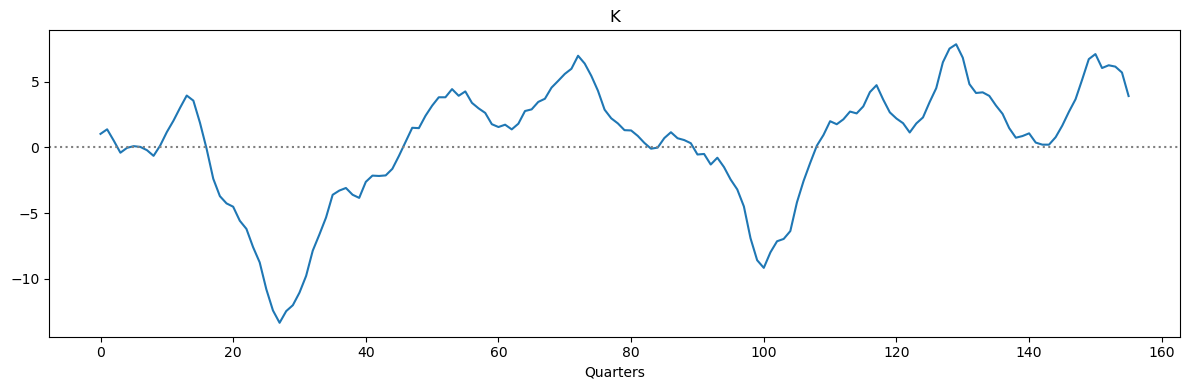

In [8]:
G = rbc_model.solve_jacobian(ss, unknowns, targets, exogenous, outputs, T=T)
shock = productivity_shock({"phi_Z": 0.8, "sigma_Z": 0.5})

impulses = shock.generate_impulses(T)
irfs = get_responses(impulses, G)

data_simul = simulate(irfs, outputs, 156)
plt = plot_timeseries(data_simul, figsize=(12, 4))

## Estimation Interface

With the current state of estimation, we use `DensityModel` to construct a log likelihood evaluator with enough context to efficiently compute a log posterior. Therefore, everything needed to compute a Jacobian must be included within this object.

There are some caveats in it's current state:
- one cannot yet perform estimation on parameters which alter the steady state
- model parameters greatly increase the time to compute, since Jacobians must be re-evaluated
- this does not yet support differentiable samplers like HMC (although this is a desirable feature)

In [9]:
# construct a density model
dsge_logpdf = DensityModel(
    data_simul, ss, rbc_model, productivity_shock,
    unknowns, targets, exogenous, T=300, sigmas=np.full(1, 0.05)
)

Included in SSJ, is a suite of samplers and distributions which are specifically designed to interface with DSGE models

In [10]:
prior = Prior({
    "phi_Z": Uniform(0.01, 0.99),
    "sigma_Z": InvGamma(3, 1)
})

For Bayesian estimation, we include a slice sampler as well as a Metropolis sampler with Gaussian proposals. For brevity, we use the latter to demonstrate it's use within SSJ

In [11]:
mh_sampler = MetropolisHastings(dsge_logpdf, prior, step_size=0.05)
mh_sampler.sample(10000)

100%|██████████| 9999/9999 [01:41<00:00, 98.45it/s] 


array([[0.        , 0.        ],
       [0.01531873, 0.22584561],
       [0.0253434 , 0.26461851],
       ...,
       [0.79809075, 0.4971723 ],
       [0.78630685, 0.4824012 ],
       [0.79411475, 0.48089095]])

In [12]:
np.mean(mh_sampler.samples, axis=0)

array([0.75997417, 0.47643558])

For MLE, estimation is simple. Using `optimagic` under the hood, we can call derivative free optimization using a similar interface as Bayesian sampling. Furthermore, the user can specify whether they want a bounded optimizer using a keyword argument (set to `False` by default)

In [13]:
mle = MaximumLikelihood(dsge_logpdf, prior)
res = mle.optimize("scipy_lbfgsb", bounded=False)

In [14]:
res.x

{'phi_Z': 0.7603590555435782, 'sigma_Z': 0.466766402691698}